In [1]:
from pathlib import Path
import sys
import os

# Add parent directory to Python path
project_root = Path("/home/nbyrnes/code/random-matrix/")  # <-- adjust this
sys.path.insert(0, str(project_root))

import pickle
import time
import warnings
import matplotlib.pyplot as plt
import matplotlib
import numpy as np
from multiprocessing import Pool, cpu_count
import itertools
import scipy.sparse
import shapely
import tqdm
import quadpy
import warnings
from random_matrix.amplitude_matrix import (
    isotropic_sphere,
    scattering_geometry,
)
from random_matrix.input_statistics import density_function, density_integrals
from random_matrix.input_statistics.density_function import (
    DeltaDensityFactor,
    DensityFunction,
    DensityFunctionTerm,
    RegularDensityFactor,
)
from random_matrix.input_statistics.index_finder import IndexFinder
from random_matrix.input_statistics.input_statistics_manager import (
    InputStatisticsManager,
)
from random_matrix.input_statistics.integration_task import (
    IntegrationTaskPreparer,
    IntegrationTaskConfig,
)
from random_matrix.input_statistics.medium_parameters import MediumParameters
from random_matrix.input_statistics.medium_statistics import (
    MediumStatistics,
    ParticleStatistics,
)
from random_matrix.input_statistics.matrix_pool_manager import (
    MatrixPoolManager,
)
from random_matrix.modes import mode_grid, mode_grid_factory
from random_matrix.utils import (
    array_utils,
    function_utils,
    geometry_utils,
    integration_utils,
    matrix_utils,
    special_functions,
)
from random_matrix.scattering_matrix.field_vector import FieldVector
from random_matrix.scattering_matrix.scattering_matrix import ScatteringMatrix
import cupy as cp
import math
from tqdm import tqdm

In [2]:
base_path = "/mnt/raid/rmt/data"
simulation_name = "memory_effect_rectangular"
pm = MatrixPoolManager(simulation_name, base_path)
pm.populate_single_pool(1, False, "S", False, None, True, True)

Loading statistics...
Loaded. Generating matrices...


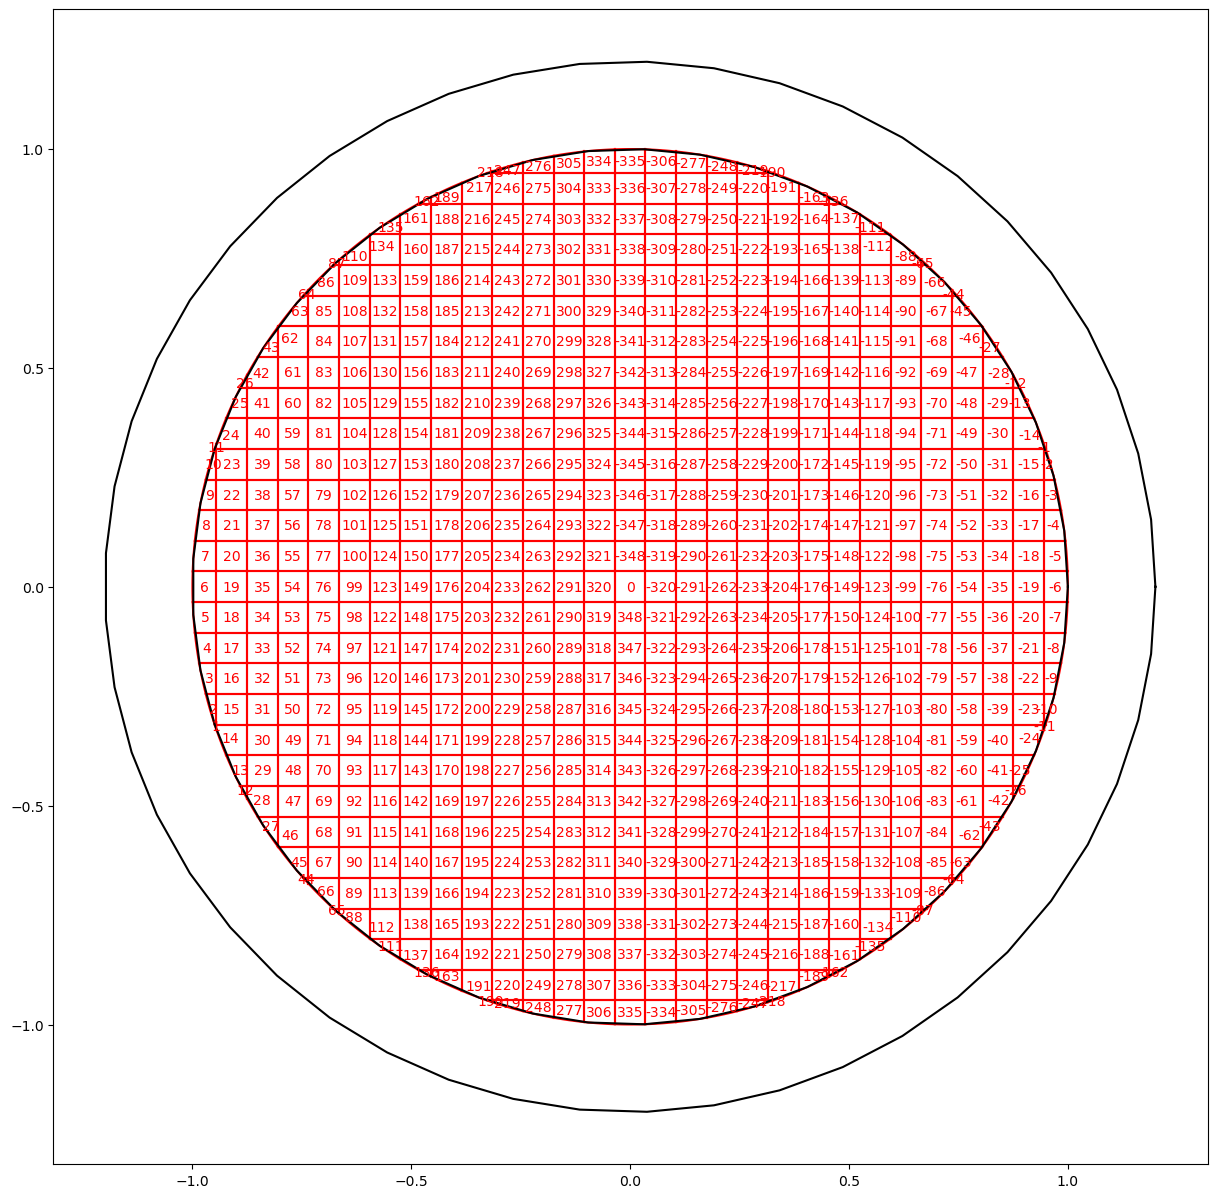

In [3]:
my_grid = pm.mode_grid
my_grid.plot(show_indices=True, figsize=(15, 15))
fv = FieldVector(my_grid)
sm = ScatteringMatrix(my_grid)

In [4]:
# Work out the spacing. Manual for now
central = my_grid.by_index(0)
off = my_grid.by_index(-320)
spacing = (off.center - central.center)[0]
print(spacing)

0.07


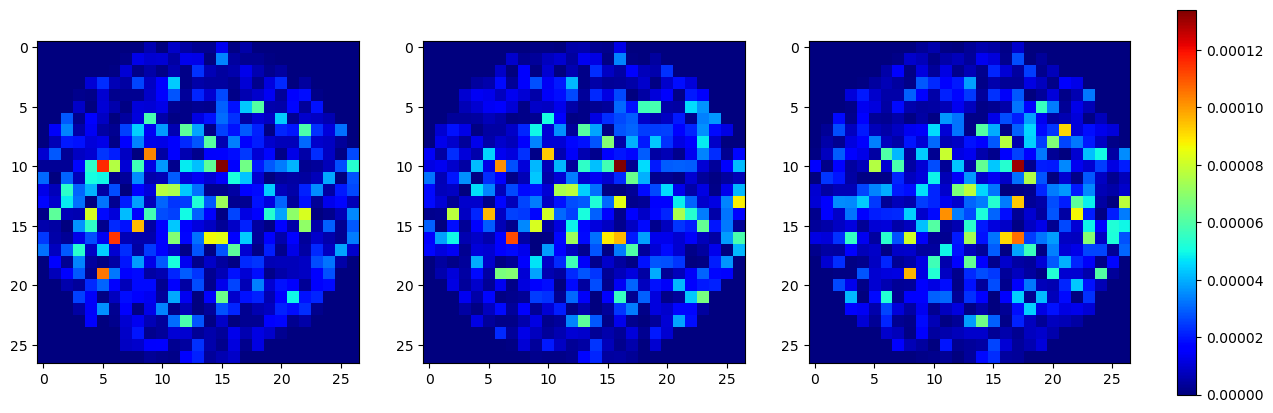

In [5]:
incident_indices = [0, -320, -291]
plot_data = [
    fv.get_2d_representation(
        sm.get_column_intensity(
            matrix_utils.get_block(pm.single_pool_S[0], "t"),
            incident_index,
            "p",
        )
    )
    for incident_index in incident_indices
]
fv.plot_imshows(plot_data)

In [6]:
def roll_with_zeros(arr, shift_y=0, shift_x=0):
    """
    Shift a 2D array like np.roll but fill edges with 0 instead of wrapping.

    Positive shift_y: shift down
    Positive shift_x: shift right
    """
    result = np.zeros_like(arr)

    # source slice
    y_src_start = max(-shift_y, 0)
    y_src_end = arr.shape[0] - max(shift_y, 0)
    x_src_start = max(-shift_x, 0)
    x_src_end = arr.shape[1] - max(shift_x, 0)

    # destination slice
    y_dst_start = max(shift_y, 0)
    y_dst_end = arr.shape[0] - max(-shift_y, 0)
    x_dst_start = max(shift_x, 0)
    x_dst_end = arr.shape[1] - max(-shift_x, 0)

    # copy the overlapping region
    result[y_dst_start:y_dst_end, x_dst_start:x_dst_end] = arr[
        y_src_start:y_src_end, x_src_start:x_src_end
    ]

    return result

In [7]:
polarization_keys = ["pp", "ps", "sp", "ss"]

incident_indices = [
    mode.index for mode in my_grid.propagating_modes_list if not mode.is_edge
]

# Extract scattering matrix blocks
t = matrix_utils.get_block(pm.single_pool_S[0], "t")
t_pp = sm.get_pp(t)
t_ps = sm.get_ps(t)
t_sp = sm.get_sp(t)
t_ss = sm.get_ss(t)

# Prepare data dictionaries
data = {
    "pp": {idx: sm.get_column(t_pp, idx) for idx in incident_indices},
    "ps": {idx: sm.get_column(t_ps, idx) for idx in incident_indices},
    "sp": {idx: sm.get_column(t_sp, idx) for idx in incident_indices},
    "ss": {idx: sm.get_column(t_ss, idx) for idx in incident_indices},
}

reference_data = {key: data[key][0] for key in polarization_keys}
reference_auto_corr = {
    key: np.sum(reference_data[key] * np.conj(reference_data[key]))
    for key in polarization_keys
}

# Correlation map setup
correlation_map_size = 27
spacing = 0.07
center_offset = correlation_map_size // 2

# Worker function for multiprocessing
def process_index(index):
    local_corr = {
        (ref_key, new_key): np.zeros((correlation_map_size, correlation_map_size), dtype=np.complex128)
        for ref_key, new_key in itertools.product(polarization_keys, repeat=2)
    }

    mode = my_grid.by_index(int(index))
    center = mode.center
    dx, dy = np.rint(center / spacing).astype(int)

    for ref_key, new_key in itertools.product(polarization_keys, repeat=2):
        new_vector = data[new_key][index]
        ref_vector = reference_data[ref_key]

        # Convert to 2D representation
        new_2d = fv.get_2d_representation(new_vector)
        ref_2d = fv.get_2d_representation(ref_vector)

        # Shift new data with zeros at edges
        new_2d_shifted = roll_with_zeros(new_2d, dy, -dx)

        # Compute normalized cross-correlation
        new_auto = np.sum(new_2d_shifted * np.conj(new_2d_shifted))
        ref_auto = reference_auto_corr[ref_key]
        cross_corr = np.sum(ref_2d * np.conj(new_2d_shifted))
        normalized = cross_corr / np.sqrt(new_auto * ref_auto)

        # Place value in correlation map
        i = dx + center_offset
        j = -dy + center_offset
        if 0 <= i < correlation_map_size and 0 <= j < correlation_map_size:
            local_corr[(ref_key, new_key)][i, j] = normalized

    return local_corr

# Run with multiprocessing
num_processes = min(cpu_count(), len(incident_indices))
with Pool(num_processes) as pool:
    results = list(tqdm(pool.imap(process_index, incident_indices), total=len(incident_indices)))

# Merge results
correlation_data = {
    key: sum(result[key] for result in results)
    for key in results[0].keys()
}

100%|██████████| 585/585 [00:21<00:00, 27.63it/s]


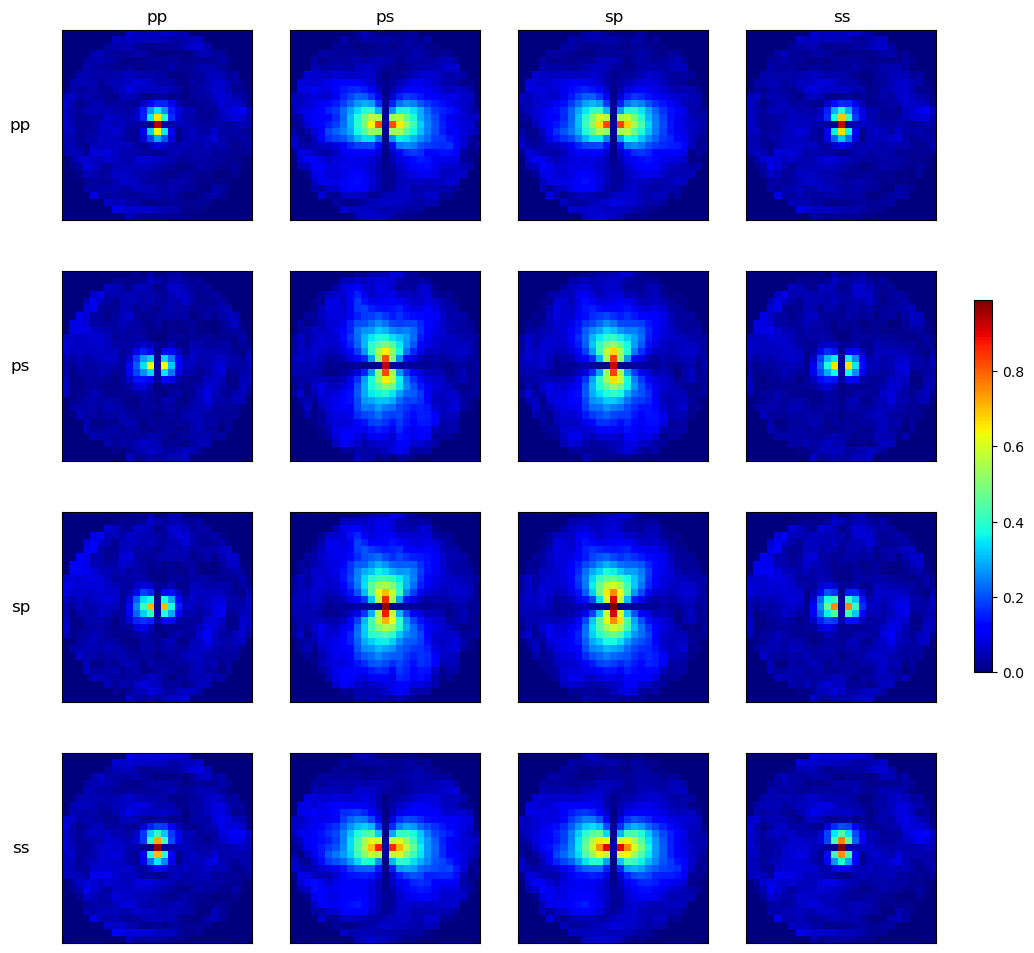

In [8]:
fig, axs = plt.subplots(4, 4, figsize=(12, 12))

# Compute global normalization
all_values = np.array([np.abs(correlation_data[key]) for key in itertools.product(polarization_keys, repeat=2)])
vmin, vmax = all_values.min(), all_values.max()
norm = plt.Normalize(vmin=vmin, vmax=vmax)
cmap = plt.cm.jet
scm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
scm.set_array([])

for i, ref_key in enumerate(polarization_keys):
    for j, new_key in enumerate(polarization_keys):
        ax = axs[i, j]
        im = ax.imshow(np.abs(correlation_data[(ref_key, new_key)]), norm=norm, cmap=cmap)
        ax.set_xticks([])
        ax.set_yticks([])

        # Only label the top row with new_key
        if i == 0:
            ax.set_title(new_key, fontsize=12)
        # Only label the left column with ref_key
        if j == 0:
            ax.set_ylabel(ref_key, fontsize=12, rotation=0, labelpad=30, va='center')

# Add single colorbar
fig.colorbar(scm, ax=axs, orientation="vertical", fraction=0.02, pad=0.04)

In [9]:
polarization_keys = ["pp", "ps", "sp", "ss"]
incident_indices = [mode.index for mode in my_grid.propagating_modes_list if not mode.is_edge]

# Extract scattering matrix blocks
t = matrix_utils.get_block(pm.single_pool_S[0], "t")
t_pp = sm.get_pp(t)
t_ps = sm.get_ps(t)
t_sp = sm.get_sp(t)
t_ss = sm.get_ss(t)

# Prepare data dictionaries
data = {
    "pp": {idx: sm.get_column(t_pp, idx) for idx in incident_indices},
    "ps": {idx: sm.get_column(t_ps, idx) for idx in incident_indices},
    "sp": {idx: sm.get_column(t_sp, idx) for idx in incident_indices},
    "ss": {idx: sm.get_column(t_ss, idx) for idx in incident_indices},
}

# Compute reference data (incident polarization only, averaged over outputs)
reference_data = {}
for ref_inc in ["p", "s"]:
    # sum of squared magnitudes across output polarizations
    combined = np.zeros_like(next(iter(data["pp"].values())), dtype=np.float64)
    for out_pol in ["p", "s"]:
        key = out_pol + ref_inc  # output + incident
        combined += np.abs(data[key][0])**2
    reference_data[ref_inc] = combined

reference_auto_corr = {key: np.sum(ref**2) for key, ref in reference_data.items()}

# Correlation map setup
correlation_map_size = 27
spacing = 0.07
center_offset = correlation_map_size // 2

def process_index_avg(index):
    """Compute correlations for one incident index, averaging over output polarizations."""
    local_corr = {
        (ref_inc, new_inc): np.zeros((correlation_map_size, correlation_map_size), dtype=np.float64)
        for ref_inc, new_inc in itertools.product(["p","s"], repeat=2)
    }

    mode = my_grid.by_index(int(index))
    center = mode.center
    dx, dy = np.rint(center / spacing).astype(int)

    for ref_inc, new_inc in itertools.product(["p","s"], repeat=2):
        # Sum intensities over output polarizations
        new_data = np.zeros_like(next(iter(data["pp"].values())), dtype=np.float64)
        for out_pol in ["p","s"]:
            key = out_pol + new_inc
            new_data += np.abs(data[key][index])**2

        ref_vector = reference_data[ref_inc]

        # Convert to 2D representation
        new_2d = fv.get_2d_representation(new_data)
        ref_2d = fv.get_2d_representation(ref_vector)

        # Shift new data with zeros at edges
        new_2d_shifted = roll_with_zeros(new_2d, dy, -dx)

        # Compute normalized cross-correlation
        new_auto = np.sum(new_2d_shifted**2)
        ref_auto = reference_auto_corr[ref_inc]
        cross_corr = np.sum(ref_2d * new_2d_shifted)
        normalized = cross_corr / np.sqrt(new_auto * ref_auto)

        # Place value in correlation map
        i = dx + center_offset
        j = -dy + center_offset
        if 0 <= i < correlation_map_size and 0 <= j < correlation_map_size:
            local_corr[(ref_inc, new_inc)][i, j] = normalized

    return local_corr

# Run with multiprocessing
num_processes = min(cpu_count(), len(incident_indices))
with Pool(num_processes) as pool:
    results = list(tqdm(pool.imap(process_index_avg, incident_indices), total=len(incident_indices)))

# Merge results
correlation_data = {
    key: sum(result[key] for result in results)
    for key in results[0].keys()
}

100%|██████████| 585/585 [00:05<00:00, 106.67it/s]


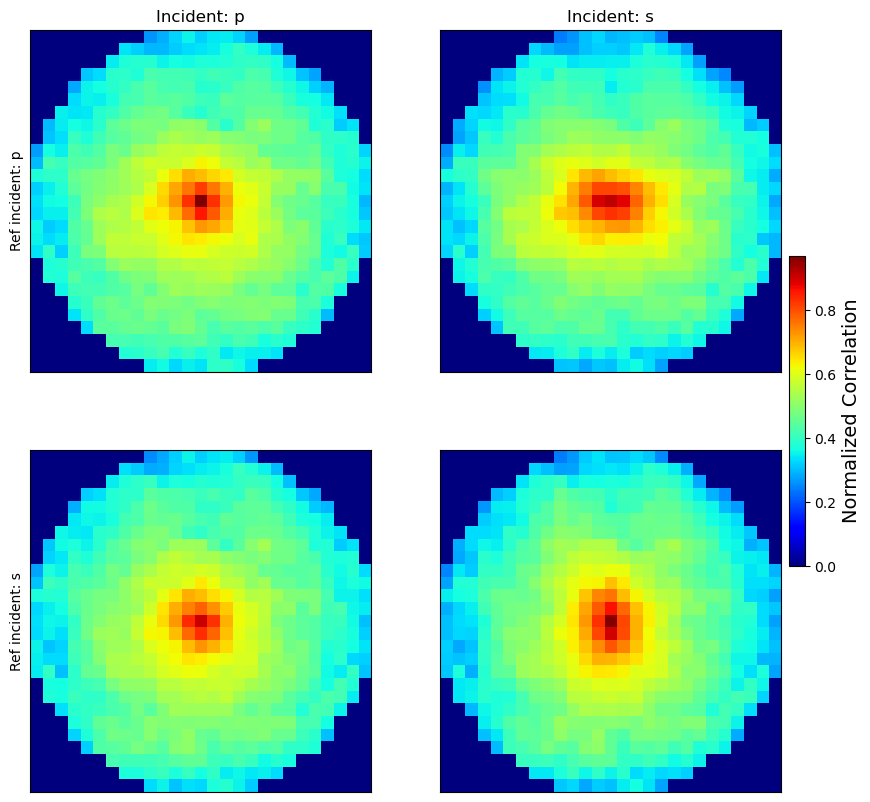

In [10]:
fig, axs = plt.subplots(2, 2, figsize=(10, 10))

all_values = np.array([correlation_data[key] for key in correlation_data])
vmin, vmax = all_values.min(), all_values.max()
norm = plt.Normalize(vmin=vmin, vmax=vmax)
cmap = plt.cm.jet

for row, ref_inc in enumerate(["p","s"]):
    for col, new_inc in enumerate(["p","s"]):
        ax = axs[row, col]
        im = ax.imshow(correlation_data[(ref_inc, new_inc)], norm=norm, cmap=cmap)
        if row == 0:
            ax.set_title(f"Incident: {new_inc}")
        if col == 0:
            ax.set_ylabel(f"Ref incident: {ref_inc}")
        ax.set_xticks([])
        ax.set_yticks([])

# Single colorbar
cbar = fig.colorbar(im, ax=axs, orientation='vertical', fraction=0.02, pad=0.01)
cbar.set_label("Normalized Correlation", fontsize=14)


In [53]:
S = pm.single_pool_S[0]
t = matrix_utils.get_block(S, "t")

# Generate data needed for the elliptical plot
interior_modes_list = [m for m in my_grid.propagating_modes_list if not m.is_edge]
interior_modes_indices = [m.index for m in interior_modes_list]

num_interior_modes = len(interior_modes_list)
# ki, kj, ku (kv is fixed)
data_array = np.zeros((num_interior_modes, num_interior_modes, num_interior_modes))
for mi in interior_modes_list:
    i = interior_modes_indices.index(mi.index)
    for mj in tqdm(interior_modes_list):
        j = interior_modes_indices.index(mj.index)
        
        dkij = mj.center - mi.center
        for mu in interior_modes_list:
            u = interior_modes_indices.index(mu.index)
            v_center = mu.center + dkij
            # Calculate v and see if there is a mode there or not
            found = False
            v_point = shapely.Point(v_center)
            for mv in interior_modes_list:
                mv_polygon = shapely.Polygon(mv.vertices)
                if mv_polygon.contains(v_point):
                    found = True 
                    break
            
            data_array[i,j,u] = 1 if found else 0
                


            


  0%|          | 2/585 [00:06<32:29,  3.34s/it]


KeyboardInterrupt: 

In [45]:
u.center

AttributeError: 'int' object has no attribute 'center'

In [ ]:
def on_click(event):
    global arrow_artist
    for i, patch in enumerate(patches):
        if patch.contains_point([event.x, event.y]):
            if len(clicked_indices) == 2:
                # Reset previous selections
                for idx in clicked_indices:
                    values[idx] = 0
                    patches[idx].set_facecolor(cmap(0))
                if arrow_artist:
                    arrow_artist.remove()
                    arrow_artist = None
                clicked_indices.clear()

            # toggle this patch
            values[i] = 1 - values[i]
            patch.set_facecolor(cmap(values[i]))
            clicked_indices.append(i)
            fig.canvas.draw_idle()

            # Once two squares are clicked, assign mi and mj
            if len(clicked_indices) == 2:
                i1, i2 = clicked_indices
                mi = interior_modes_list[i1]
                mj = interior_modes_list[i2]
                print(f"mi = {mi}")
                print(f"mj = {mj}")

                # draw arrow
                c1, c2 = centers[i1], centers[i2]
                arrow_artist = ax_control.arrow(c1[0], c1[1], c2[0]-c1[0], c2[1]-c1[1],
                                                head_width=0.02, head_length=0.02,
                                                fc='red', ec='red')
                fig.canvas.draw_idle()

            break
